In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [3]:
reduced_data = pd.read_csv("../../datasets/redundancy_30_with_transition_boundaries_with_cleavage_sites.csv")
reduced_data.head()

,entry_id,sequence,kingdom,sp_type,annotation,transition_boundaries,cleavage_site
0,Q8TF40,MAPTLFQKLFSKRTGLGAPGRDARDPDCGFSWPLPEFDPSQIRLIV...,EUKARYA,NO_SP,IIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIII...,[],NaN
1,Q1ENB6,MDFTSLETTTFEEVVIALGSNVGNRMNNFKEALRLMKDYGISVTRH...,EUKARYA,NO_SP,IIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIII...,[],NaN
2,P36001,MDDISGRQTLPRINRLLEHVGNPQDSLSILHIAGTNGKETVSKFLT...,EUKARYA,NO_SP,IIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIII...,[],NaN
3,P55317,MLGTVKMEGHETSDWNSYYADTQEAYSSVPVSNMNSGLGSMNSMNT...,EUKARYA,NO_SP,IIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIII...,[],NaN
4,Q9PSY4,MTLSSDMSDVLAEETDIDVVGEEDEPRAEEEEEEDGELLMPRSPHC...,EUKARYA,NO_SP,IIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIII...,[],NaN


## Analysis of all sequences

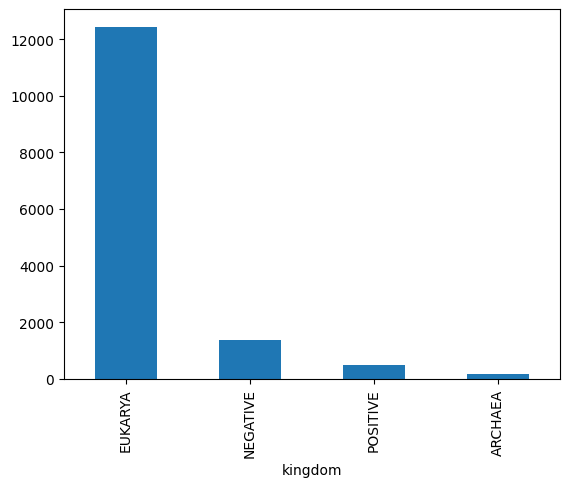

In [4]:
# kingdom distribution
reduced_data['kingdom'].value_counts().plot(kind='bar')
plt.show()

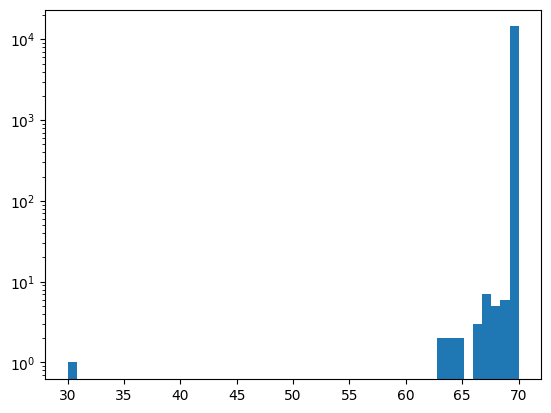

In [5]:
# length distribution
reduced_data["length"] = reduced_data["sequence"].apply(lambda seq: len(seq))
plt.hist(reduced_data["length"], bins=50)
plt.yscale("log")
plt.show()

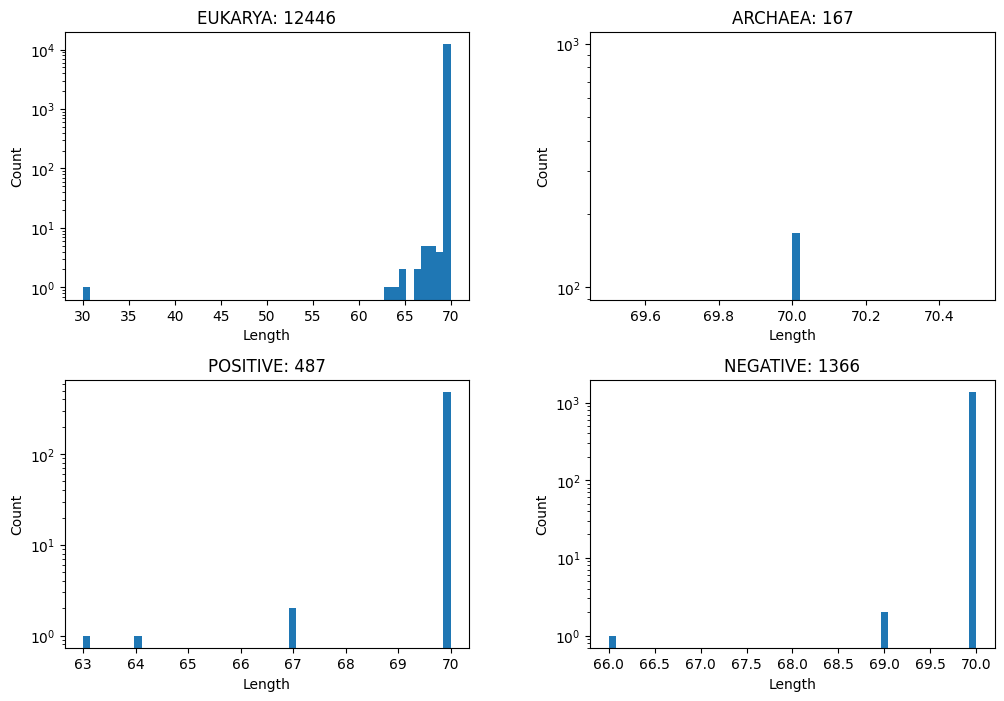

In [6]:
# per kingdom length distribution
fig, ax = plt.subplots(2, 2, figsize=(12, 8))
ax = ax.flatten()
for kingdom, a in zip(reduced_data["kingdom"].unique(), ax):
    a.hist(reduced_data[reduced_data["kingdom"] == kingdom]["length"], bins=50)
    a.set_yscale("log")
    a.set_title(f"{kingdom}: {len(reduced_data[reduced_data["kingdom"] == kingdom]["length"])}")
    a.set_ylabel("Count")
    a.set_xlabel("Length")

plt.subplots_adjust(hspace=0.3, wspace=0.3)
plt.show()

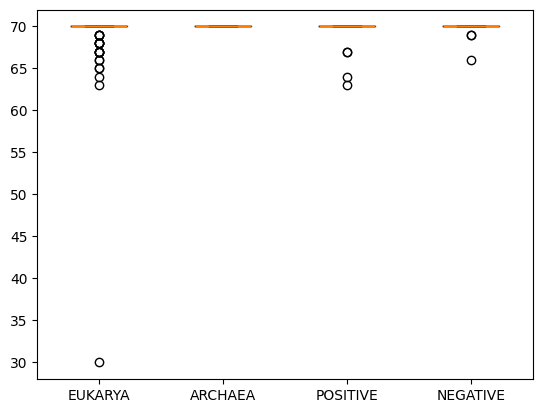

In [7]:
# per kingdom length distribution boxplot
data = []
plt.boxplot([reduced_data[reduced_data["kingdom"] == kingdom]["length"] for kingdom in reduced_data["kingdom"].unique()], tick_labels=[kingdom for kingdom in reduced_data["kingdom"].unique()])
plt.show()

In [8]:
# percentage not 70 per kingdom
for kingdom in reduced_data["kingdom"].unique():
    print(f"{kingdom}: Relative: {(len(reduced_data[(reduced_data["kingdom"] == kingdom) & (reduced_data["length"] != 70)]["length"]) / len(reduced_data[reduced_data["kingdom"] == kingdom])) * 100:.2f}%, Total: {len(reduced_data[(reduced_data["kingdom"] == kingdom) & (reduced_data["length"] != 70)]["length"])}")

EUKARYA: Relative: 0.17%, Total: 21
ARCHAEA: Relative: 0.00%, Total: 0
POSITIVE: Relative: 0.82%, Total: 4
NEGATIVE: Relative: 0.22%, Total: 3


## Analysis of Signal Peptide Containing Sequences

In [9]:
print(f"Signal Peptide Percentage: {(len(reduced_data[reduced_data["sp_type"] != "NO_SP"]) / len(reduced_data)) * 100:.2f}%")
for kingdom in reduced_data["kingdom"].unique():
    print(f"Signal Peptide Percentage {kingdom}: {(len(reduced_data[(reduced_data["sp_type"] != "NO_SP") & (reduced_data["kingdom"] == kingdom)]) / len(reduced_data[reduced_data["kingdom"] == kingdom])) * 100:.2f}%")

Signal Peptide Percentage: 14.80%
Signal Peptide Percentage EUKARYA: 9.10%
Signal Peptide Percentage ARCHAEA: 44.31%
Signal Peptide Percentage POSITIVE: 61.40%
Signal Peptide Percentage NEGATIVE: 46.56%


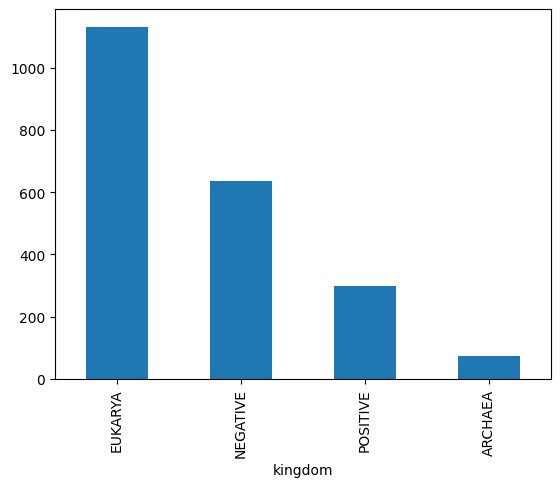

In [10]:
reduced_data[reduced_data["sp_type"] != "NO_SP"]["kingdom"].value_counts().plot(kind="bar")
plt.show()

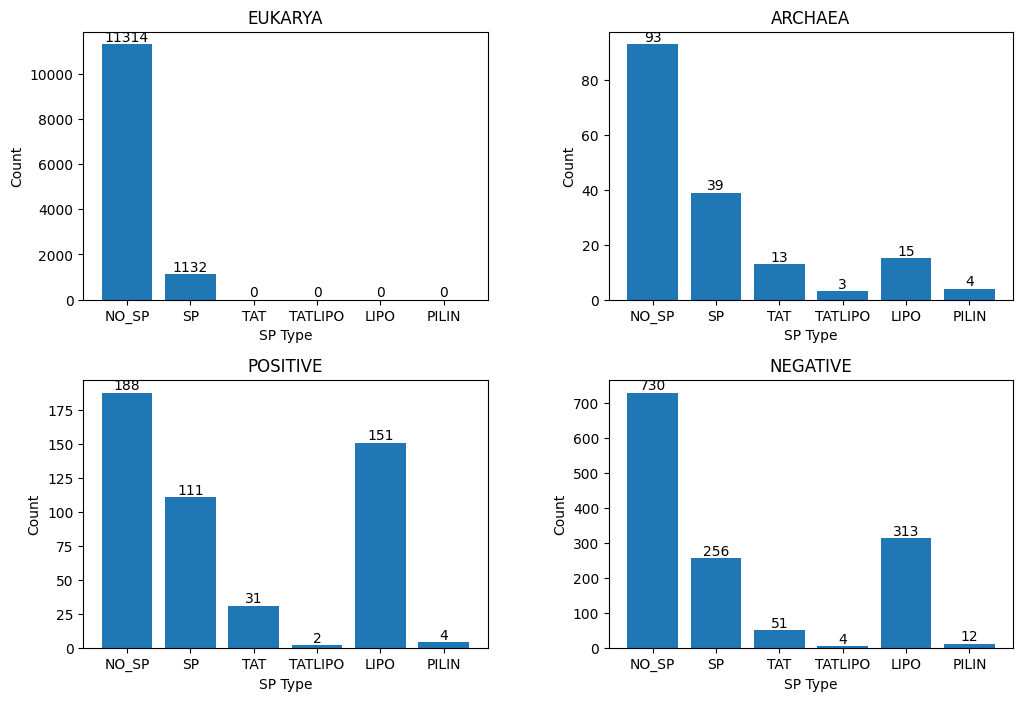

In [11]:
# per kingdom type distribution
fig, ax = plt.subplots(2, 2, figsize=(12, 8))
ax = ax.flatten()
sp_types = reduced_data["sp_type"].unique()

for kingdom, a in zip(reduced_data["kingdom"].unique(), ax):
    a.set_title(kingdom)
    bars = a.bar(
        sp_types, 
        [len(reduced_data[(reduced_data["kingdom"] == kingdom) & (reduced_data["sp_type"] == sp_type)]) for sp_type in sp_types],
    )
    for bar in bars:
        a.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), bar.get_height(), ha="center", va="bottom")
    a.set_ylabel("Count")
    a.set_xlabel("SP Type")

plt.subplots_adjust(hspace=0.3, wspace=0.3)
plt.show()

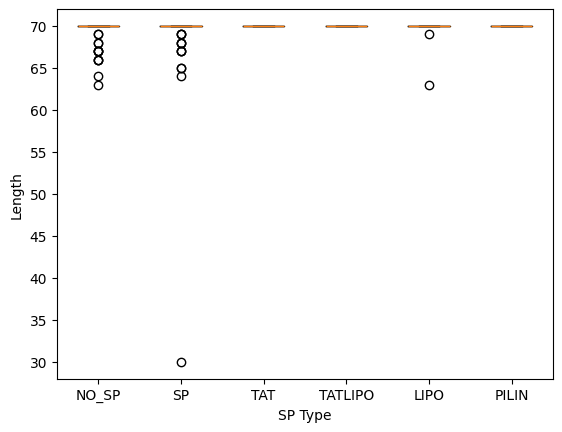

In [12]:
# per type length distribution
plt.boxplot([reduced_data[reduced_data["sp_type"] == sp_type]["length"] for sp_type in sp_types], tick_labels=sp_types)
plt.ylabel("Length")
plt.xlabel("SP Type")
plt.show()

In [14]:
for sp_type in sp_types:
    print(f"Sub 70 Percentage {sp_type}: Relative: {(len(reduced_data[(reduced_data["sp_type"] == sp_type) & (reduced_data["length"] != 70)]) / len(reduced_data[reduced_data["sp_type"] == sp_type])) * 100:.2f}%, Total: {len(reduced_data[(reduced_data["sp_type"] == sp_type) & (reduced_data["length"] != 70)])}")

Sub 70 Percentage NO_SP: Relative: 0.11%, Total: 13
Sub 70 Percentage SP: Relative: 0.85%, Total: 13
Sub 70 Percentage TAT: Relative: 0.00%, Total: 0
Sub 70 Percentage TATLIPO: Relative: 0.00%, Total: 0
Sub 70 Percentage LIPO: Relative: 0.42%, Total: 2
Sub 70 Percentage PILIN: Relative: 0.00%, Total: 0
